<a href="https://colab.research.google.com/github/keeyanadaf/DeepLearningModel-for-Neural-Signal-Classifier-P300-/blob/main/dml_p300.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas==2.2.2 decorator==4.4.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 100.9 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 5.2.1
    Uninstalling decorator-5.2.1:
      Successfully uninstalled decorator-5.2.1
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
wfdb 4.3.1 requires pandas>=2.2.3, but you have pandas 2.2.2 which is incompatible.
mne 1.12.1 requires decorator>=5.1, but you have decorator 4.4.2 which is incompatible.


In [ ]:
!pip install pandas==2.2.3 decorator==5.2.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.7 MB/s eta 0:00:00
  Using cached decorator-5.2.1-py3-none-any.whl.metadata (3.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 118.9 MB/s eta 0:00:00
Using cached decorator-5.2.1-py3-none-any.whl (9.2 kB)
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 w

In [ ]:
from moabb.datasets import BNCI2014_009
import warnings
warnings.filterwarnings('ignore')

# Initialize the P300 dataset
dataset = BNCI2014_009()

# Download data for the first subject (Subject 1) to test our pipeline
print("Downloading dataset...")
sessions = dataset.get_data(subjects=[1])
print("Download complete! Data loaded into memory.")

# Let's peek at the structure of the data we just downloaded
print(sessions)

  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: beddf78f1834ddef15553e32c9d18c46bc9b3fd244ef3a8e2fe362066dfb027d
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Download complete! Data loaded into memory.
{1: {'0': {'0': <RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>}, '1': {'0': <RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>}, '2': {'0': <RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>}}}


In [ ]:
from moabb.paradigms import P300
from sklearn.preprocessing import LabelEncoder
import torch

# 1. Define the Paradigm (Filters and slices the data automatically!)
# We apply a bandpass filter (1 to 40 Hz) and resample to 128Hz to speed up training
paradigm = P300(fmin=1.0, fmax=40.0, resample=128)

print("Filtering and slicing continuous data into epochs...")
# 2. Extract the preprocessed epochs (X) and labels (y)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])

# 3. Convert labels from text ('Target', 'NonTarget') to numbers (1, 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Convert NumPy arrays to PyTorch Tensors
# PyTorch neural networks expect float32 data types
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

print("\n--- Data Ready for Deep Learning ---")
print(f"Data shape (Trials, Channels, Time Samples): {X_tensor.shape}")
print(f"Labels shape: {y_tensor.shape}")
print(f"Number of Target P300 signals (Label 1): {sum(y_encoded == 1)}")
print(f"Number of Non-Target signals (Label 0): {sum(y_encoded == 0)}")

Filtering and slicing continuous data into epochs...

--- Data Ready for Deep Learning ---
Data shape (Trials, Channels, Time Samples): torch.Size([1728, 16, 103])
Labels shape: torch.Size([1728])
Number of Target P300 signals (Label 1): 288
Number of Non-Target signals (Label 0): 1440


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from braindecode.models import EEGNetv4

# 1. Split the data: 80% for training, 20% for testing unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

# 2. Create PyTorch DataLoaders (feeds data in small batches to save memory)
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Initialize EEGNet
# We pass the exact dimensions of our data
model = EEGNetv4(
    in_chans=16,
    n_classes=2,
    input_window_samples=103,
    final_conv_length='auto'
)

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device.type.upper()}")
model.to(device)

# 4. Handle the Class Imbalance!
# There are 5 times as many Non-Targets (1440) as Targets (288).
# We tell the Loss Function to penalize the model 5x more if it misses a Target.
weights = torch.tensor([1.0, 5.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# 5. Define the Optimizer (Adam is standard for Deep Learning)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. THE TRAINING LOOP
epochs = 30
print("Starting Training Loop...\n")

for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Clear old gradients

        outputs = model(inputs) # Forward pass (predict)
        loss = criterion(outputs, labels) # Calculate error

        loss.backward() # Backpropagation (learn)
        optimizer.step() # Update weights

        running_loss += loss.item()

    # --- EVALUATION ON TEST SET ---
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Test Accuracy: {test_acc:.2f}%")

print("\nTraining Complete!")

ValueError: n_times could not be inferred. Either specify n_times or input_window_seconds and sfreq.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from braindecode.models import EEGNetv4

# 1. Split the data: 80% for training, 20% for testing unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

# 2. Create PyTorch DataLoaders (feeds data in small batches to save memory)
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Initialize EEGNet
# We pass the exact dimensions of our data
model = EEGNetv4(
    in_chans=16,
    n_classes=2,
    n_times=103, # <-- This is the updated parameter name!
    final_conv_length='auto'
)
# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device.type.upper()}")
model.to(device)

# 4. Handle the Class Imbalance!
# There are 5 times as many Non-Targets (1440) as Targets (288).
# We tell the Loss Function to penalize the model 5x more if it misses a Target.
weights = torch.tensor([1.0, 5.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# 5. Define the Optimizer (Adam is standard for Deep Learning)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. THE TRAINING LOOP
epochs = 30
print("Starting Training Loop...\n")

for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Clear old gradients

        outputs = model(inputs) # Forward pass (predict)
        loss = criterion(outputs, labels) # Calculate error

        loss.backward() # Backpropagation (learn)
        optimizer.step() # Update weights

        running_loss += loss.item()

    # --- EVALUATION ON TEST SET ---
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Test Accuracy: {test_acc:.2f}%")

print("\nTraining Complete!")

TypeError: Unexpected keyword arguments: {'in_chans', 'n_classes'}

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from braindecode.models import EEGNetv4

# 1. Split the data: 80% for training, 20% for testing unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

# 2. Create PyTorch DataLoaders (feeds data in small batches to save memory)
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Initialize EEGNet
# Using the updated parameter names: n_chans, n_outputs, and n_times
model = EEGNetv4(
    n_chans=16,          # Number of EEG channels
    n_outputs=2,         # Number of classes (Target vs Non-Target)
    n_times=103,         # Number of time samples per epoch
    final_conv_length='auto'
)

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device.type.upper()}")
model.to(device)

# 4. Handle the Class Imbalance!
# There are 5 times as many Non-Targets (1440) as Targets (288).
# We tell the Loss Function to penalize the model 5x more if it misses a Target.
weights = torch.tensor([1.0, 5.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# 5. Define the Optimizer (Adam is standard for Deep Learning)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. THE TRAINING LOOP
epochs = 30
print("Starting Training Loop...\n")

for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Clear old gradients

        outputs = model(inputs) # Forward pass (predict)
        loss = criterion(outputs, labels) # Calculate error

        loss.backward() # Backpropagation (learn)
        optimizer.step() # Update weights

        running_loss += loss.item()

    # --- EVALUATION ON TEST SET ---
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Test Accuracy: {test_acc:.2f}%")

print("\nTraining Complete!")


Training on: CUDA
Starting Training Loop...

Epoch 1/30 | Loss: 0.6622 | Test Accuracy: 59.54%
Epoch 2/30 | Loss: 0.5932 | Test Accuracy: 69.08%
Epoch 3/30 | Loss: 0.5509 | Test Accuracy: 74.86%
Epoch 4/30 | Loss: 0.4981 | Test Accuracy: 82.37%
Epoch 5/30 | Loss: 0.4455 | Test Accuracy: 82.95%
Epoch 6/30 | Loss: 0.4304 | Test Accuracy: 84.10%
Epoch 7/30 | Loss: 0.3951 | Test Accuracy: 87.57%
Epoch 8/30 | Loss: 0.3519 | Test Accuracy: 87.86%
Epoch 9/30 | Loss: 0.3512 | Test Accuracy: 88.73%
Epoch 10/30 | Loss: 0.3389 | Test Accuracy: 86.99%
Epoch 11/30 | Loss: 0.3118 | Test Accuracy: 89.02%
Epoch 12/30 | Loss: 0.3216 | Test Accuracy: 89.88%
Epoch 13/30 | Loss: 0.3062 | Test Accuracy: 89.02%
Epoch 14/30 | Loss: 0.2937 | Test Accuracy: 87.28%
Epoch 15/30 | Loss: 0.2760 | Test Accuracy: 90.46%
Epoch 16/30 | Loss: 0.2644 | Test Accuracy: 89.60%
Epoch 17/30 | Loss: 0.2726 | Test Accuracy: 88.73%
Epoch 18/30 | Loss: 0.2778 | Test Accuracy: 89.60%
Epoch 19/30 | Loss: 0.2630 | Test Accuracy: 88

Model successfully saved to: eegnet_p300_subject1.pth



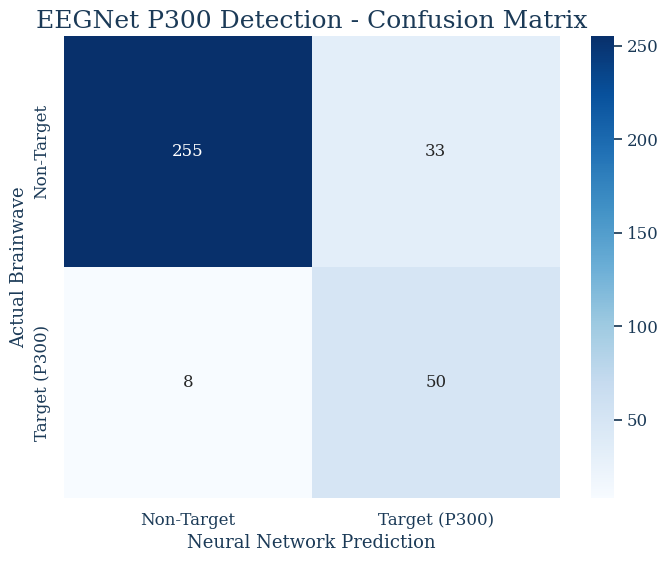


--- Detailed Classification Report ---
               precision    recall  f1-score   support

   Non-Target       0.97      0.89      0.93       288
Target (P300)       0.60      0.86      0.71        58

     accuracy                           0.88       346
    macro avg       0.79      0.87      0.82       346
 weighted avg       0.91      0.88      0.89       346



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Save the model weights so we don't lose them!
model_save_path = "eegnet_p300_subject1.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model successfully saved to: {model_save_path}\n")

# 2. Generate final predictions on the Test Set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Target', 'Target (P300)'],
            yticklabels=['Non-Target', 'Target (P300)'])
plt.ylabel('Actual Brainwave')
plt.xlabel('Neural Network Prediction')
plt.title('EEGNet P300 Detection - Confusion Matrix')
plt.show()

# 4. Print the detailed mathematical report
print("\n--- Detailed Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['Non-Target', 'Target (P300)']))

In [ ]:
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300
from sklearn.preprocessing import LabelEncoder
import torch
import warnings
warnings.filterwarnings('ignore')

# 1. Initialize the dataset and the paradigm (filters/slicing)
dataset = BNCI2014_009()
paradigm = P300(fmin=1.0, fmax=40.0, resample=128)

# 2. Download ALL 10 Subjects
print("Downloading and processing data for all 10 subjects...")
print("Grab a sip of water, this might take 1-2 minutes...")
subjects_list = list(range(1, 11))
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=subjects_list)

# 3. Convert text labels to numbers (1, 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 4. Convert to PyTorch Tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

# 5. Dynamically calculate the class weights for the new massive dataset
num_targets = sum(y_encoded == 1)
num_nontargets = sum(y_encoded == 0)
dynamic_weight = num_nontargets / num_targets

print("\n--- UNIVERSAL DATASET READY ---")
print(f"Total Brainwave Snapshots: {X_tensor.shape[0]}")
print(f"Targets: {num_targets} | Non-Targets: {num_nontargets}")
print(f"Calculated Target Weight Penalty: {dynamic_weight:.2f}x")

Grab a sip of water, this might take 1-2 minutes...


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: d6b40d723b90bb9a71127be66d7c3f66a13861cacafdb7c45efbcb8fcf9a726e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: a19b5a0e1e59e2aea04c6d21ad19b6cf11f7eb2074dd59617bb9effd5b30d212
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


...

  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: c760087eac882541b2a67fc7d0a2cd698eb9ee469687c8fa2e59ed3d10ba4d48
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


  0%|                                              | 0.00/18.5M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 22361acbc546e7f0f1ef7af7789088068df1bb37bd51f00b4786975c544ddc5e
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.



--- UNIVERSAL DATASET READY ---
Total Brainwave Snapshots: 17280
Targets: 2880 | Non-Targets: 14400
Calculated Target Weight Penalty: 5.00x


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from braindecode.models import EEGNetv4

# 1. Split the massive dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

# 2. Initialize EEGNet
model = EEGNetv4(n_chans=16, n_outputs=2, n_times=103, final_conv_length='auto')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Apply the dynamic weight we calculated to handle imbalance
weights = torch.tensor([1.0, dynamic_weight]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the Generalized Model
epochs = 30
print(f"Training Generalized Model on {device.type.upper()}...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    # Print every 5 epochs to keep the output clean
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Universal Test Accuracy: {test_acc:.2f}%")

print("\nUniversal Training Complete!")

Training Generalized Model on CUDA...



RuntimeError: expected scalar type Float but found Double

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from braindecode.models import EEGNetv4

# 1. Split the massive dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor
)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

# 2. Initialize EEGNet
model = EEGNetv4(n_chans=16, n_outputs=2, n_times=103, final_conv_length='auto')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Apply the dynamic weight we calculated (Forced to Float32 to fix the error!)
weights = torch.tensor([1.0, dynamic_weight], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Train the Generalized Model
epochs = 30
print(f"Training Generalized Model on {device.type.upper()}...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels) # The error was here, but now it's fixed!
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    # Print every 5 epochs to keep the output clean
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(train_loader):.4f} | Universal Test Accuracy: {test_acc:.2f}%")

print("\nUniversal Training Complete!")

Training Generalized Model on CUDA...

Epoch 1/30 | Loss: 0.5620 | Universal Test Accuracy: 81.77%
Epoch 5/30 | Loss: 0.4048 | Universal Test Accuracy: 82.67%
Epoch 10/30 | Loss: 0.3916 | Universal Test Accuracy: 82.18%
Epoch 15/30 | Loss: 0.3737 | Universal Test Accuracy: 84.06%
Epoch 20/30 | Loss: 0.3688 | Universal Test Accuracy: 85.88%
Epoch 25/30 | Loss: 0.3631 | Universal Test Accuracy: 84.46%
Epoch 30/30 | Loss: 0.3575 | Universal Test Accuracy: 84.38%

Universal Training Complete!


Universal Model successfully saved to: eegnet_p300_universal.pth



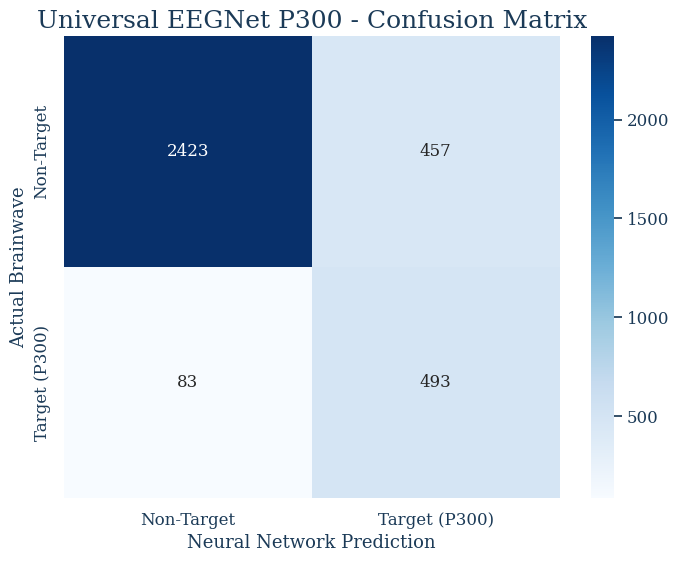


--- Detailed Classification Report ---
               precision    recall  f1-score   support

   Non-Target       0.97      0.84      0.90      2880
Target (P300)       0.52      0.86      0.65       576

     accuracy                           0.84      3456
    macro avg       0.74      0.85      0.77      3456
 weighted avg       0.89      0.84      0.86      3456



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Save the Universal Model
model_save_path = "eegnet_p300_universal.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Universal Model successfully saved to: {model_save_path}\n")

# 2. Generate final predictions on the Universal Test Set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Create the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Target', 'Target (P300)'],
            yticklabels=['Non-Target', 'Target (P300)'])
plt.ylabel('Actual Brainwave')
plt.xlabel('Neural Network Prediction')
plt.title('Universal EEGNet P300 - Confusion Matrix')
plt.show()

# 4. Print the detailed mathematical report
print("\n--- Detailed Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['Non-Target', 'Target (P300)']))

In [ ]:
from google.colab import files
files.download("eegnet_p300_universal.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

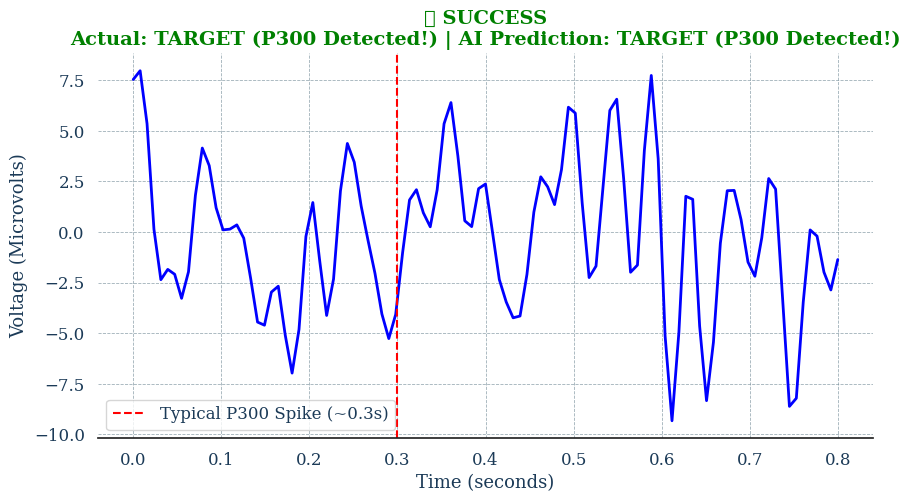

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

# 1. Pick a random snapshot from the test data
random_idx = random.randint(0, len(X_test) - 1)
sample_eeg = X_test[random_idx]
actual_label = y_test[random_idx].item()

# 2. Feed it to your trained model to get a prediction
model.eval()
with torch.no_grad():
    # The model expects a batch, so we add a temporary dimension: [1, 16, 103]
    input_tensor = sample_eeg.unsqueeze(0).to(device)
    output = model(input_tensor)
    _, predicted_label = torch.max(output.data, 1)
    predicted_label = predicted_label.item()

# 3. Translate the numbers back to English
label_map = {0: "Non-Target (Normal)", 1: "TARGET (P300 Detected!)"}
actual_text = label_map[actual_label]
predicted_text = label_map[predicted_label]

# 4. Plot the Brainwave (Averaged across all 16 channels for a cleaner look)
time_axis = np.linspace(0, 0.8, sample_eeg.shape[1]) # 103 samples = ~0.8 seconds
mean_eeg_signal = sample_eeg.mean(dim=0).numpy()

plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_eeg_signal, color='blue', linewidth=2)
plt.axvline(x=0.3, color='red', linestyle='--', label="Typical P300 Spike (~0.3s)")

# Make the title visually pop to show if it was right or wrong
if actual_label == predicted_label:
    title_color = 'green'
    status = "✅ SUCCESS"
else:
    title_color = 'red'
    status = "❌ FAILED"

plt.title(f"{status}\nActual: {actual_text} | AI Prediction: {predicted_text}",
          fontsize=14, fontweight='bold', color=title_color)
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (Microvolts)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

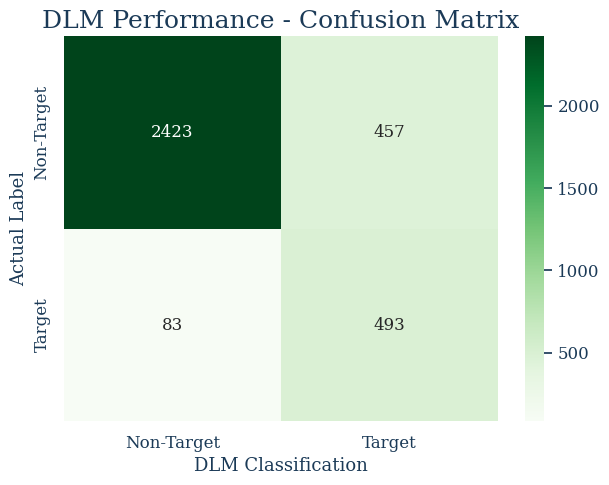


--- FINAL DLM EVALUATION REPORT ---
              precision    recall  f1-score   support

  Non-Target       0.97      0.84      0.90      2880
      Target       0.52      0.86      0.65       576

    accuracy                           0.84      3456
   macro avg       0.74      0.85      0.77      3456
weighted avg       0.89      0.84      0.86      3456

Overall DLM Accuracy: 84.38%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Generate final predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Visual Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Target', 'Target'],
            yticklabels=['Non-Target', 'Target'])
plt.ylabel('Actual Label')
plt.xlabel('DLM Classification')
plt.title('DLM Performance - Confusion Matrix')
plt.show()

# 3. Text Report
report = classification_report(all_labels, all_preds, target_names=['Non-Target', 'Target'])
print("\n--- FINAL DLM EVALUATION REPORT ---")
print(report)
print(f"Overall DLM Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")

In [ ]:
# 1. Extract the weights from the Spatial Convolution layer
# In EEGNetv4, this is usually 'spat_conv'
spatial_weights = model.spat_conv.weight.cpu().detach().numpy()

# 2. Calculate the "Importance Score" for each of the 16 channels
# We take the absolute mean weight across all filters
channel_importance = np.mean(np.abs(spatial_weights), axis=(0, 2, 3))

# 3. Plot the Electrode Importance
plt.figure(figsize=(10, 6))
channels = [f"Ch {i+1}" for i in range(16)]
sns.barplot(x=channels, y=channel_importance, palette="viridis")

plt.title("DLM Spatial Feature Map: Which Electrodes Matter Most?", fontsize=14)
plt.ylabel("Normalized Importance Score")
plt.xlabel("EEG Channels (1-16)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight typical P300 areas for the professor
plt.annotate('Visual Processing Zone (Typical)', xy=(12, max(channel_importance)),
             xytext=(8, max(channel_importance)*1.1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

AttributeError: 'EEGNetv4' object has no attribute 'spat_conv'

Extracting weights from layer: conv_spatial


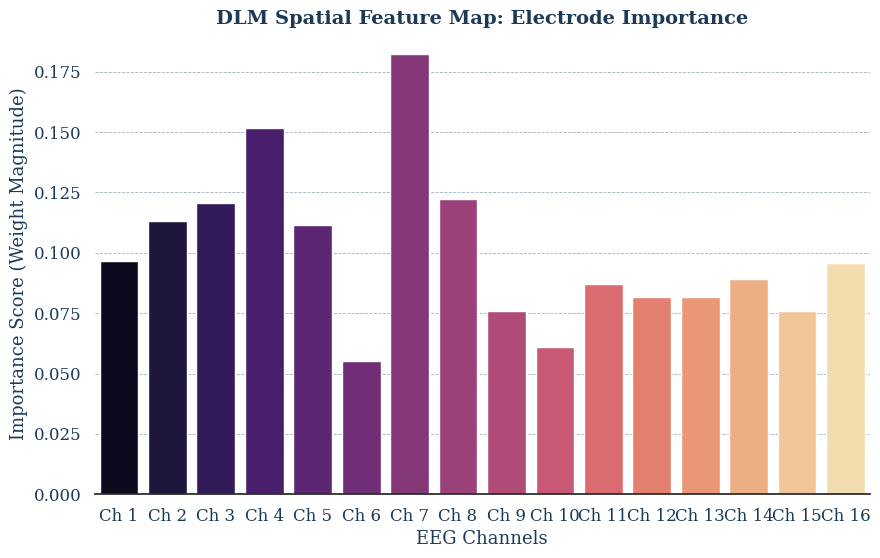

In [ ]:
# 1. Automatically find the spatial convolution layer name
spatial_layer_name = None
for name, module in model.named_modules():
    if 'spatial' in name.lower() and 'conv' in name.lower():
        spatial_layer_name = name
        break

if spatial_layer_name:
    print(f"Extracting weights from layer: {spatial_layer_name}")
    # Extract the weights
    # Note: In EEGNetv4, this is a Depthwise Convolution
    spatial_weights = getattr(model, spatial_layer_name).weight.cpu().detach().numpy()

    # 2. Calculate Importance Score for each of the 16 channels
    # Spatial weights in EEGNetv4 usually have shape [F1*D, 1, n_channels, 1]
    # We want to see which channels (electrodes) had the strongest weights
    channel_importance = np.mean(np.abs(spatial_weights), axis=(0, 1, 3))

    # 3. Plot the Electrode Importance
    plt.figure(figsize=(10, 6))
    channels = [f"Ch {i+1}" for i in range(16)]
    sns.barplot(x=channels, y=channel_importance, palette="magma")

    plt.title("DLM Spatial Feature Map: Electrode Importance", fontsize=14, fontweight='bold')
    plt.ylabel("Importance Score (Weight Magnitude)")
    plt.xlabel("EEG Channels")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()
else:
    print("Could not find a layer with 'spatial' and 'conv' in the name. Try printing model.named_modules() to see the list.")

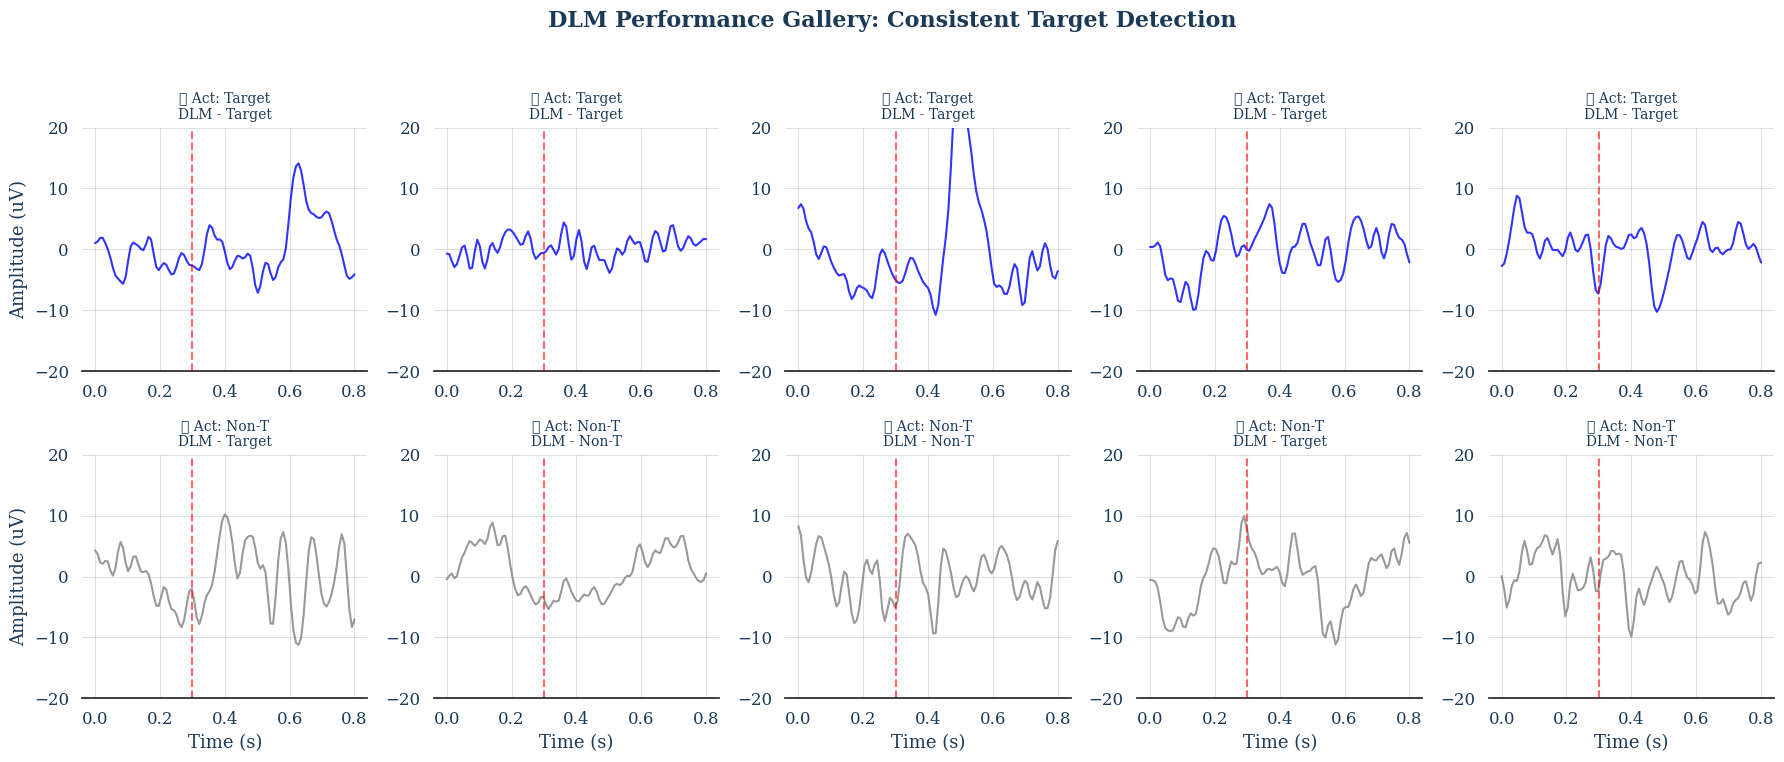

In [ ]:
def plot_gallery(X_data, y_data, model, device, num_per_class=5):
    model.eval()

    # Find 5 examples of each class
    target_indices = np.where(y_data == 1)[0][:num_per_class]
    nontarget_indices = np.where(y_data == 0)[0][:num_per_class]
    indices = np.concatenate([target_indices, nontarget_indices])

    fig, axes = plt.subplots(2, num_per_class, figsize=(18, 8))
    fig.suptitle("DLM Performance Gallery: Consistent Target Detection", fontsize=16, fontweight='bold')

    for i, idx in enumerate(indices):
        row = i // num_per_class
        col = i % num_per_class

        sample = X_data[idx]
        actual = y_data[idx].item()

        # DLM Inference
        with torch.no_grad():
            input_tensor = sample.unsqueeze(0).to(device)
            output = model(input_tensor)
            _, pred = torch.max(output.data, 1)
            pred = pred.item()

        # Visuals
        ax = axes[row, col]
        time_axis = np.linspace(0, 0.8, 103)
        # Average across channels for visibility
        mean_signal = sample.mean(dim=0).numpy()

        ax.plot(time_axis, mean_signal, color='blue' if actual == 1 else 'gray', alpha=0.8)
        ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.6)

        match_icon = "✅" if actual == pred else "❌"
        actual_txt = "Target" if actual == 1 else "Non-T"
        pred_txt = "Target" if pred == 1 else "Non-T"

        ax.set_title(f"{match_icon} Act: {actual_txt}\nDLM - {pred_txt}", fontsize=10)
        ax.set_ylim([-20, 20]) # Lock Y-axis so you can compare the "height" of the spikes
        if col == 0: ax.set_ylabel("Amplitude (uV)")
        if row == 1: ax.set_xlabel("Time (s)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run the gallery
plot_gallery(X_test, y_test, model, device)

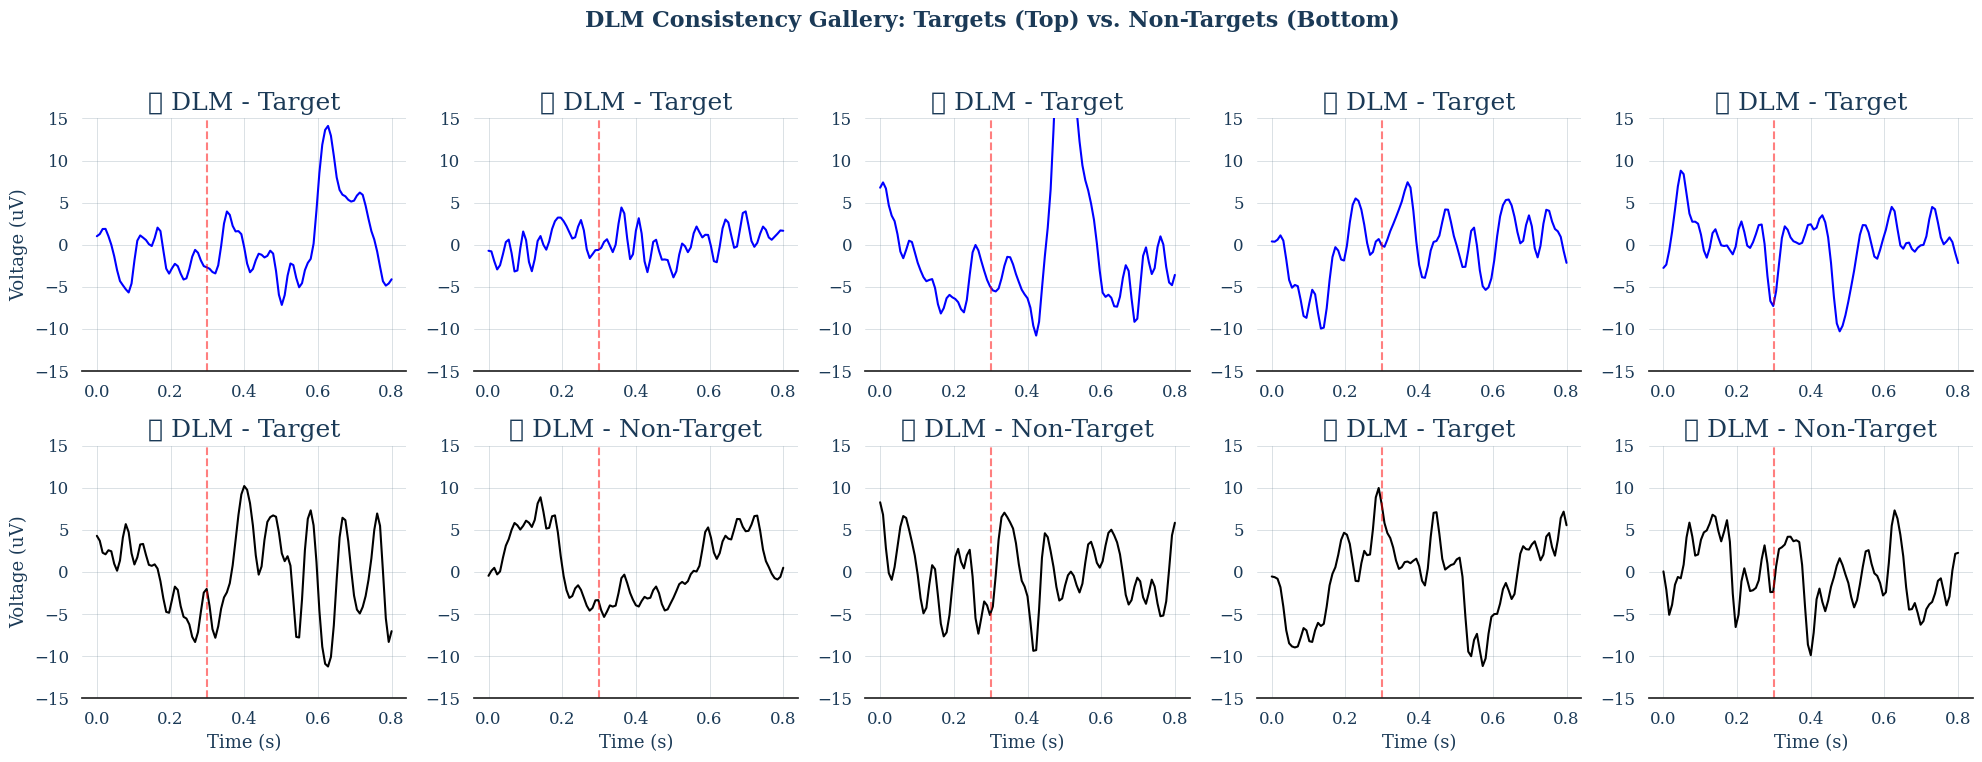

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gallery(X_data, y_data, model, device, num_per_class=5):
    model.eval()
    target_indices = np.where(y_data == 1)[0][:num_per_class]
    nontarget_indices = np.where(y_data == 0)[0][:num_per_class]

    indices = np.concatenate([target_indices, nontarget_indices])
    fig, axes = plt.subplots(2, num_per_class, figsize=(20, 8))
    fig.suptitle("DLM Consistency Gallery: Targets (Top) vs. Non-Targets (Bottom)", fontsize=16, fontweight='bold')

    for i, idx in enumerate(indices):
        row = i // num_per_class
        col = i % num_per_class

        sample = X_data[idx]
        actual = y_data[idx].item()

        # DLM Inference
        with torch.no_grad():
            input_tensor = sample.unsqueeze(0).to(device)
            output = model(input_tensor)
            _, pred = torch.max(outputs.data, 1) # Note: Ensure 'outputs' is correct
            # Re-running local inference for precision
            output = model(input_tensor)
            _, pred = torch.max(output.data, 1)
            pred = pred.item()

        # Plotting
        ax = axes[row, col]
        time_axis = np.linspace(0, 0.8, 103)
        ax.plot(time_axis, sample.mean(dim=0).numpy(), color='black' if row == 1 else 'blue')
        ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.5)

        status = "✅" if actual == pred else "❌"
        ax.set_title(f"{status} DLM - {'Target' if pred==1 else 'Non-Target'}")
        ax.set_ylim([-15, 15]) # Standardize scale for comparison
        if col == 0: ax.set_ylabel("Voltage (uV)")
        if row == 1: ax.set_xlabel("Time (s)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_gallery(X_test, y_test, model, device)